In [1]:
library(tidyverse)
library(ggplot2)
library(dplyr)
library(tidyr)
library(broom)
library(rddensity)
# Load data
data <- read_csv("../data/final-data3.csv")
names(data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 439149 Columns: 110
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (94): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "contractid"          "planid"              "fips"               
  [4] "n_nonmiss"           "avg_enrollment"      "sd_enrollment"      
  [7] "min_enrollment"      "max_enrollment"      "first_enrollment"   
 [10] "last_enrollment"     "state"               "county"             
 [13] "org_type"            "plan_type"           "partd"              
 [16] "snp"                 "eghp"                "org_name"           
 [19] "org_marketing_name"  "plan_name"           "parent_org"         
 [22] "contract_date"       "state_long"          "county_long"        
 [25] "n_elig"              "n_enrol"             "avg_eligibles"      
 [28] "sd_eligibles"        "min_eligibles"       "max_eligibles"      
 [31] "first_eligibles"     "last_eligibles"      "avg_enrolled"       
 [34] "sd_enrolled"         "min_enrolled"        "max_enrolled"       
 [37] "first_enrolled"      "last_enrolled"       "ssa"                
 [40] "ncount"              "breastcancer_screen" "rectalcancer_screen"
 [43] "cv_diab_cholscreen"  "glaucoma_test"       "monitoring"         
 [46] "flu_vaccine"         "pn_vaccine"          "physical_health"    
 [49] "mental_health"       "osteo_test"          "physical_monitor"   
 [52] "primaryaccess"       "osteo_manage"        "diab_healthy"       
 [55] "bloodpressure"       "ra_manage"           "copd_test"          
 [58] "bladder"             "falling"             "nodelays"           
 [61] "doctor_communicate"  "carequickly"         "customer_service"   
 [64] "overallrating_care"  "overallrating_plan"  "complaints_plan"    
 [67] "appeals_timely"      "appeals_review"      "leave_plan"         
 [70] "audit_problems"      "hold_times"          "info_accuracy"      
 [73] "ttyt_available"      "new_contract"        "partc_score"        
 [76] "partcd_score"        "Star_Rating"         "aged_parta"         
 [79] "aged_partb"          "risk_ab"             "risk_star5"         
 [82] "risk_star45"         "risk_star4"          "risk_star35"        
 [85] "risk_star3"          "risk_star25"         "risk_bonus5"        
 [88] "risk_bonus35"        "risk_bonus0"         "year"               
 [91] "ma_rate"             "cv_cholscreen"       "diab_cholscreen"    
 [94] "diabetes_eye"        "diabetes_kidney"     "diabetes_bloodsugar"
 [97] "diabetes_chol"       "corrective_action"   "low_score"          
[100] "org_parent"          "bmi_assess"          "older_medication"   
[103] "older_function"      "older_pain"          "readmissions"       
[106] "access_problems"     "coordination"        "improve"            
[109] "enroll_timely"       "specialneeds_manage"

# Question 1: Table of Summary statistics 
Provide a table of summary statistics showing the mean star rating, mean number of enrollments, and mean market share for plans by year. The variables (star rating, enrollments, market share) should be listed as columns and years (2010-2015) as rows. Provide an additional column reflecting the total number of plans underlying your summary statistics in each year.

In [2]:
table <- data %>%
    mutate(market_share = (avg_enrollment / avg_eligibles)) %>%
    group_by(year) %>%
    summarize(
        "Mean Star Rating" = mean(Star_Rating, na.rm = TRUE),
        "Mean Enrollment" = mean(avg_enrollment, na.rm = TRUE),
        "Mean Market Share" = mean(market_share, na.rm = TRUE),
        "Plan Count" = n()
    )%>%

mutate(across(starts_with("mean"), \(x) round(x, 2)))

table

year,Mean Star Rating,Mean Enrollment,Mean Market Share,Plan Count
<dbl>,<dbl>,<dbl>,<dbl>,<int>
2010,2.97,256.35,0.01,108222
2011,3.26,343.36,0.01,68003
2012,3.36,377.34,0.02,67246
2013,3.55,395.52,0.02,67835
2014,3.81,436.64,0.02,62344
2015,3.96,469.68,0.02,65499


# Question 2: Table of Summary statistics for plans without a star rating
Repeat part 1 but focusing only on plans without a star rating. Naturally, in this case, you need only present the mean enrollments and market share, not the mean star rating, along with a column showing the count of all such plans in each year.

In [3]:
no_star_plans <- data %>%
    filter(is.na(Star_Rating))
table_no_stars <- no_star_plans %>%
    mutate(market_share = (avg_enrollment / avg_eligibles) ) %>%
    group_by(year) %>%
    summarize(
        "Mean enrollment" = mean(avg_enrollment, na.rm = TRUE),
        "Mean Market Share" = mean(market_share, na.rm = TRUE),
        "Plan COunt" = n()
    ) %>%
mutate(across(starts_with("mean"), \(x) round(x, 2)))

table_no_stars

year,Mean enrollment,Mean Market Share,Plan COunt
<dbl>,<dbl>,<dbl>,<int>
2010,107.34,0.01,48643
2011,167.90,0.01,12754
2012,172.73,0.01,9077
2013,213.50,0.02,3661
2014,257.60,0.02,3708
2015,314.21,0.01,4680


# Question 3: Bar graphs showing the distribution of star ratings in 2010, 2012, and 2015
Provide bar graphs showing the distribution of star ratings in 2010, 2012, and 2015. How has this distribution changed over time?

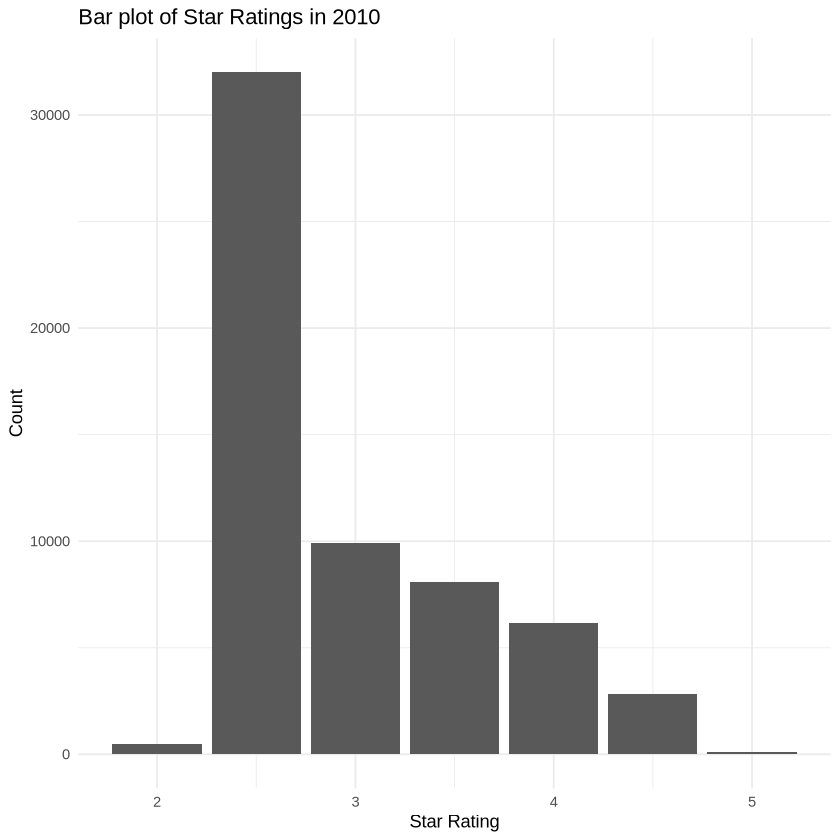

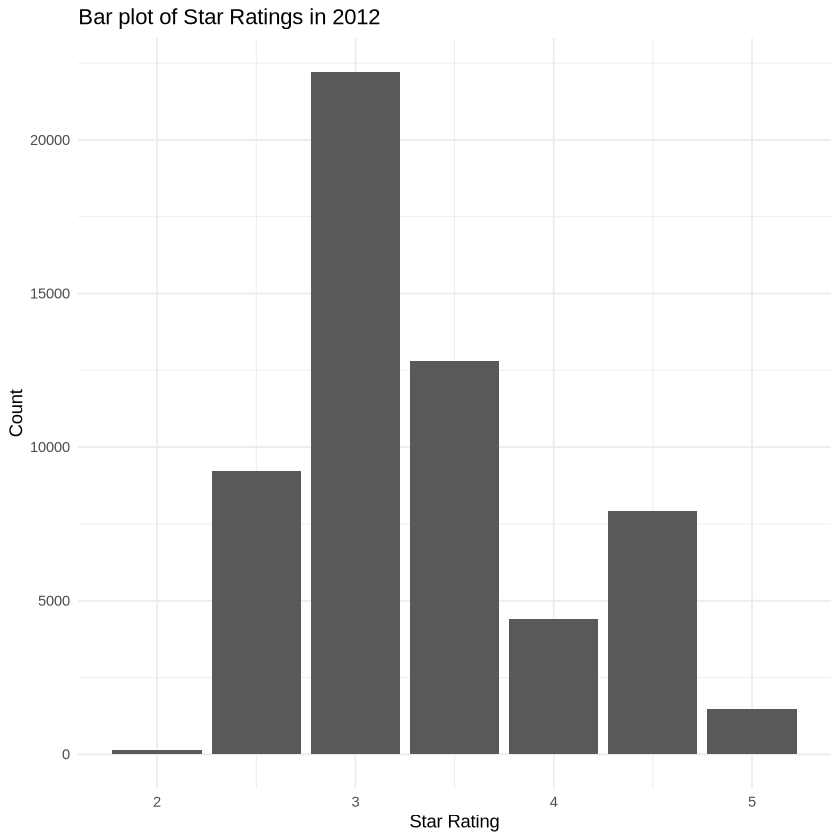

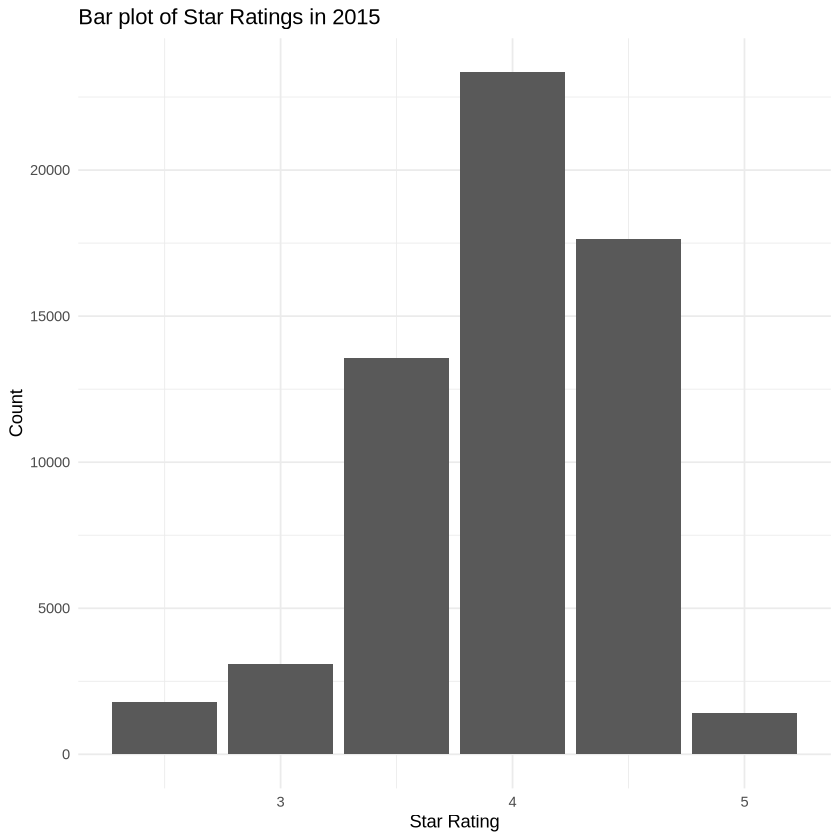

In [4]:
# Bar graph for 2010
star_ratings <- data %>%
    filter(!is.na(Star_Rating))

ggplot(filter(star_ratings, year == 2010), aes(x = Star_Rating)) +
    geom_bar() +
    labs(
        title = "Bar plot of Star Ratings in 2010",
        x = "Star Rating",
        y = "Count") +
    theme_minimal()

# Bar graph for 2012
ggplot(filter(star_ratings, year == 2012), aes(x = Star_Rating)) +
    geom_bar() +
    labs(
        title = "Bar plot of Star Ratings in 2012",
        x = "Star Rating",
        y = "Count") +
    theme_minimal()

# Bar graph for 2015
ggplot(filter(star_ratings, year == 2015), aes(x = Star_Rating)) +
    geom_bar() +
    labs(
        title = "Bar plot of Star Ratings in 2015",
        x = "Star Rating",
        y = "Count") +
    theme_minimal()


 Over time there are s,ignificantly fewer plans, there goes from almost 49,000 plans in 2010 to less than 5,000 plans by 2015. Not only does the number of plans dereas, but the quality of plans increases. In 2010 a majority of plans had a star rating of 2.5, in 2012 most were 3 star, and by 2015 the largest category was 4 stars. 

# Question 4: Table showing regression results from OLS of market share on star ratings for 2010-2015
Provide a table showing the regression resuls from an ordinary least squares regression of market share on star ratings, again for each year from 2010 through 2015. In this table, the rows should reflect your coefficient estimates and the columns should reflect different estimates for each year. In your regression specifications, please treat star ratings of 2.5 or below as your excluded category, and include indicator variables for star ratings of 3, 3.5, 4, and 4.5 or above.

In [5]:
star_ratings <- data %>%
    filter(!is.na(Star_Rating))
OLS_model <- data %>%
    mutate(market_share = (avg_enrollment / avg_eligibles) ) %>%
    group_by(year) %>%
    do(tidy(lm(market_share ~ Star_Rating, data = .))) %>%
    select(year, term, estimate)
final_regression_table <- OLS_model %>%
    pivot_wider(names_from = year, values_from = estimate)
final_regression_table

term,2010,2011,2012,2013,2014,2015
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.002924309,0.002518522,0.010193352,0.006751156,0.010253461,0.010147547
Star_Rating,0.004998232,0.003797972,0.001869752,0.002680871,0.002023896,0.002349627


In [6]:
# Filter data
high_star_plans <- data %>%
    mutate(market_share = (avg_enrollment / avg_eligibles) ) %>%
    mutate(star_cat = case_when(
        Star_Rating <= 2.5 ~ "2.5 or below",
        Star_Rating == 3.0 ~ "3.0",
        Star_Rating == 3.5 ~ "3.5",
        Star_Rating == 4.0 ~ "4.0",
        Star_Rating >= 4.5 ~ "4.5 or above"
  )) %>%
    mutate(star_cat = factor(star_cat,
                             levels = c("2.5 or below", "3.0", "3.5", "4.0", "4.5 or above")))
# run OLS
OLS_model <- high_star_plans %>%
    group_by(year) %>%
    do(tidy(lm(market_share ~ star_cat, data = high_star_plans))) %>%
    select(year, term, estimate)
final_regression_table <- OLS_model %>%
    pivot_wider(names_from = year, values_from = estimate)
final_regression_table

term,2010,2011,2012,2013,2014,2015
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.009038089,0.009038089,0.009038089,0.009038089,0.009038089,0.009038089
star_cat3.0,0.007878647,0.007878647,0.007878647,0.007878647,0.007878647,0.007878647
star_cat3.5,0.008591866,0.008591866,0.008591866,0.008591866,0.008591866,0.008591866
star_cat4.0,0.008144926,0.008144926,0.008144926,0.008144926,0.008144926,0.008144926
star_cat4.5 or above,0.010203956,0.010203956,0.010203956,0.010203956,0.010203956,0.010203956


In [7]:
# Load 2010 data only
data2010 <- read_csv("../data/data-2010.csv")
names(data2010)
library(rdrobust)

Rows: 108222 Columns: 91
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (66): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl (10): partcd_score, risk_star5, risk_star45, risk_star4, risk_star35, ri...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "contractid"          "planid"              "fips"               
 [4] "n_nonmiss"           "avg_enrollment"      "sd_enrollment"      
 [7] "min_enrollment"      "max_enrollment"      "first_enrollment"   
[10] "last_enrollment"     "state"               "county"             
[13] "org_type"            "plan_type"           "partd"              
[16] "snp"                 "eghp"                "org_name"           
[19] "org_marketing_name"  "plan_name"           "parent_org"         
[22] "contract_date"       "state_long"          "county_long"        
[25] "n_elig"              "n_enrol"             "avg_eligibles"      
[28] "sd_eligibles"        "min_eligibles"       "max_eligibles"      
[31] "first_eligibles"     "last_eligibles"      "avg_enrolled"       
[34] "sd_enrolled"         "min_enrolled"        "max_enrolled"       
[37] "first_enrolled"      "last_enrolled"       "ssa"                
[40] "ncount"              "breastcancer_screen" "rectalcancer_screen"
[43] "cv_diab_cholscreen"  "glaucoma_test"       "monitoring"         
[46] "flu_vaccine"         "pn_vaccine"          "physical_health"    
[49] "mental_health"       "osteo_test"          "physical_monitor"   
[52] "primaryaccess"       "osteo_manage"        "diab_healthy"       
[55] "bloodpressure"       "ra_manage"           "copd_test"          
[58] "bladder"             "falling"             "nodelays"           
[61] "doctor_communicate"  "carequickly"         "customer_service"   
[64] "overallrating_care"  "overallrating_plan"  "complaints_plan"    
[67] "appeals_timely"      "appeals_review"      "leave_plan"         
[70] "audit_problems"      "hold_times"          "info_accuracy"      
[73] "ttyt_available"      "new_contract"        "partc_score"        
[76] "partcd_score"        "Star_Rating"         "aged_parta"         
[79] "aged_partb"          "risk_ab"             "risk_star5"         
[82] "risk_star45"         "risk_star4"          "risk_star35"        
[85] "risk_star3"          "risk_star25"         "risk_bonus5"        
[88] "risk_bonus35"        "risk_bonus0"         "year"               
[91] "ma_rate"

# Question 5: Calculate the running variable underlying the star rating with a table showing the number of rounded plans 3-5 star
Calculate the running variable underlying the star rating. Provide a table showing the number of plans that are rounded up into a 3-star, 3.5-star, 4-star, 4.5-star, and 5-star rating.

In [8]:
# Calculate the running variable 
data_cleaned <- data2010 %>%
  mutate(raw_score = rowMeans(select(., breastcancer_screen:ttyt_available), na.rm = TRUE))

# Create table and filter for plans that were "rounded up" 
rounded_up_table <- data_cleaned %>%
  filter(Star_Rating > raw_score) %>%
  filter(Star_Rating %in% c(3, 3.5, 4, 4.5, 5)) %>%
  group_by(Star_Rating) %>%
  summarise(num_plans_rounded_up = n()) %>%
  arrange(Star_Rating)

rounded_up_table

Star_Rating,num_plans_rounded_up
<dbl>,<int>
3.0,3748
3.5,4444
4.0,5929
4.5,2831
5.0,102


# Question 6: Using the RD estimator with a bandwith of 0.125 show estimate of the effect of 3 star versus 2.5 star on enrollments
Using the RD estimator with a bandwidth of 0.125, provide an estimate of the effect of receiving a 3-star versus a 2.5 star rating on enrollments. Repeat the exercise to estimate the effects at 3.5 stars, and summarize your results in a table.

In [9]:
data_cleaned <- data2010 %>%
  mutate(raw_score = rowMeans(select(., breastcancer_screen:ttyt_available), na.rm = TRUE))
# Define variables for the RD estimator
rd_result <- rdrobust(y = data_cleaned$avg_enrolled,
                      x = data_cleaned$raw_score,
                      c = 2.75,
                      h = 0.125)

summary(rd_result)

Sharp RD estimates using local polynomial regression.

Number of Obs.                93425
BW type                      Manual
Kernel                   Triangular
VCE method                       NN

Number of Obs.                54473        38952
Eff. Number of Obs.           22178         2510
Order est. (p)                    1            1
Order bias  (q)                   2            2
BW est. (h)                   0.125        0.125
BW bias (b)                   0.125        0.125
rho (h/b)                     1.000        1.000
Unique Obs.                   54473        38952

        Method     Coef. Std. Err.         z     P>|z|      [ 95% C.I. ]       
  Conventional 21616.728  1625.018    13.302     0.000 [18431.752 , 24801.705] 
        Robust         -         -    15.872     0.000 [30827.457 , 39513.583] 


### estimate the effect at 3.5 stars

In [10]:
# Define variables for the RD estimator
rd_result <- rdrobust(y = data_cleaned$avg_enrolled,
                      x = data_cleaned$raw_score,
                      c = 3.25,
                      h = 0.125)

summary(rd_result)

Sharp RD estimates using local polynomial regression.

Number of Obs.                93425
BW type                      Manual
Kernel                   Triangular
VCE method                       NN

Number of Obs.                73128        20297
Eff. Number of Obs.            2608         2322
Order est. (p)                    1            1
Order bias  (q)                   2            2
BW est. (h)                   0.125        0.125
BW bias (b)                   0.125        0.125
rho (h/b)                     1.000        1.000
Unique Obs.                   73128        20297

        Method     Coef. Std. Err.         z     P>|z|      [ 95% C.I. ]       
  Conventional-18408.589  3525.068    -5.222     0.000[-25317.596 , -11499.582]
        Robust         -         -    -1.530     0.126[-16784.583 , 2070.124]  


# Question 7: Repeat question 6 with alternative bandwidths
Repeat your results for bandwidhts of 0.1, 0.12, 0.13, 0.14, and 0.15 (again for 3 and 3.5 stars). Show all of the results in a graph. How sensitive are your findings to the choice of bandwidth?

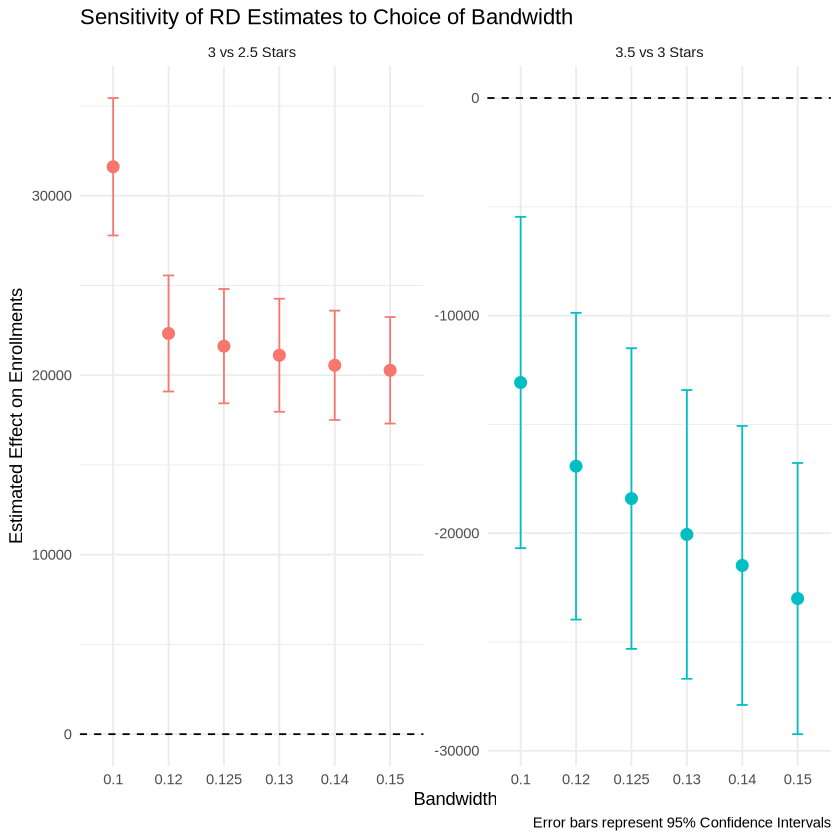

In [11]:
# Define the bandwidths to test
bws <- c(0.1, 0.12, 0.125, 0.13, 0.14, 0.15)

# Initialize an empty list to store results
results_list <- list()

# Loop through each bandwidth
for (bw in bws) {
  
  # Estimate for 3 stars
  rd_3 <- rdrobust(y = data_cleaned$avg_enrolled, x = data_cleaned$raw_score, c = 2.75, h = bw)
  results_list[[paste0("3star_", bw)]] <- data.frame(
    Rating = "3 vs 2.5 Stars",
    Bandwidth = bw,
    Estimate = rd_3$coef[1],
    CI_Lower = rd_3$ci[1,1],
    CI_Upper = rd_3$ci[1,2]
  )
  
  # Estimate for 3.5 stars
  rd_35 <- rdrobust(y = data_cleaned$avg_enrolled, x = data_cleaned$raw_score, c = 3.25, h = bw)
  results_list[[paste0("3.5star_", bw)]] <- data.frame(
    Rating = "3.5 vs 3 Stars",
    Bandwidth = bw,
    Estimate = rd_35$coef[1],
    CI_Lower = rd_35$ci[1,1],
    CI_Upper = rd_35$ci[1,2]
  )
}

# Combine all results into one dataframe
sensitivity_df <- bind_rows(results_list)

# Plot the results
ggplot(sensitivity_df, aes(x = as.factor(Bandwidth), y = Estimate, color = Rating)) +
  geom_point(position = position_dodge(width = 0.5), size = 3) +
  geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                position = position_dodge(width = 0.5), width = 0.2) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  facet_wrap(~Rating, scales = "free_y") +
  labs(title = "Sensitivity of RD Estimates to Choice of Bandwidth",
       x = "Bandwidth",
       y = "Estimated Effect on Enrollments",
       caption = "Error bars represent 95% Confidence Intervals") +
  theme_minimal() +
  theme(legend.position = "none")

The direction of the effect is consistent across all bandwidth choices. For the 3-star threshold it is consistently positive and for the 3.5-star it is negative. As the bandwidth increases from 0.1 to 0.15 for estimated effect for the 3-star plans slightly decreases, with the most significant different being between 0.1 and 0.12. For the 3.5-star plans the decrease becomes more pronounced. Additionally, the 3.5 star estimates have a much wider confidence interval.

# Question 8: Distribution of the running variable before and after the releant threshold values
Examine (graphically) whether contracts appear to manipulate the running variable. In other words, look at the distribution of the running variable before and after the relevent threshold values. What do you find?

Warning message in rddensity(X = data_cleaned$raw_score, c = 2.75):
“14330 missing observations are ignored.
”
Warning message in rdplotdensity(rdd = dens_test_275, X = data_cleaned$raw_score, :
“14330 missing observations are ignored.
”
Warning message in rddensity(X = data_cleaned$raw_score, c = 3.25):
“14330 missing observations are ignored.
”
Warning message in rdplotdensity(rdd = dens_test_325, X = data_cleaned$raw_score, :
“14330 missing observations are ignored.
”


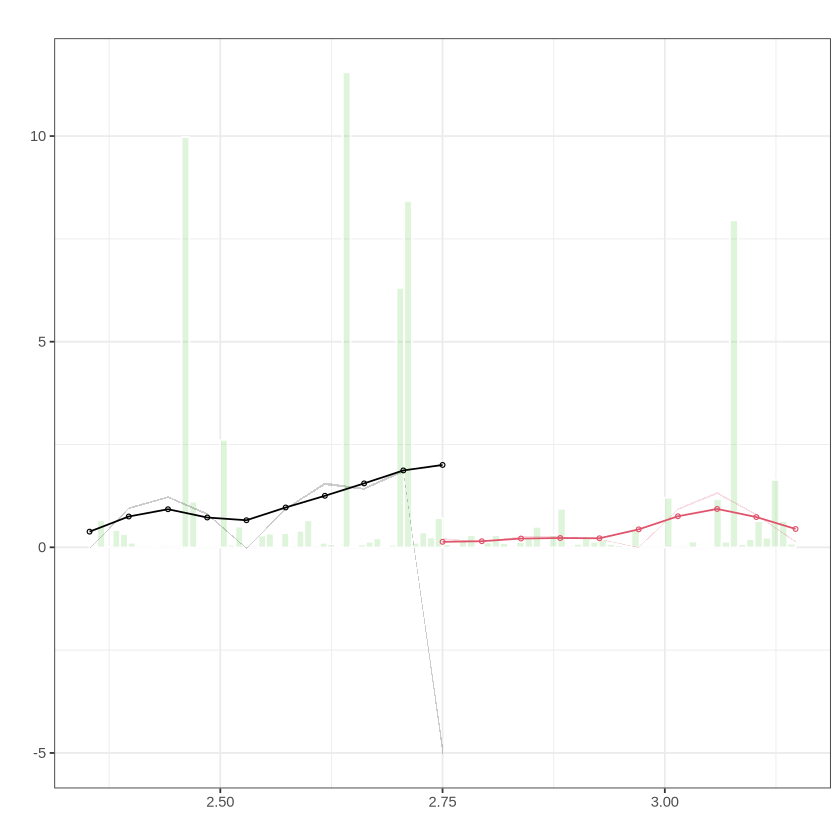

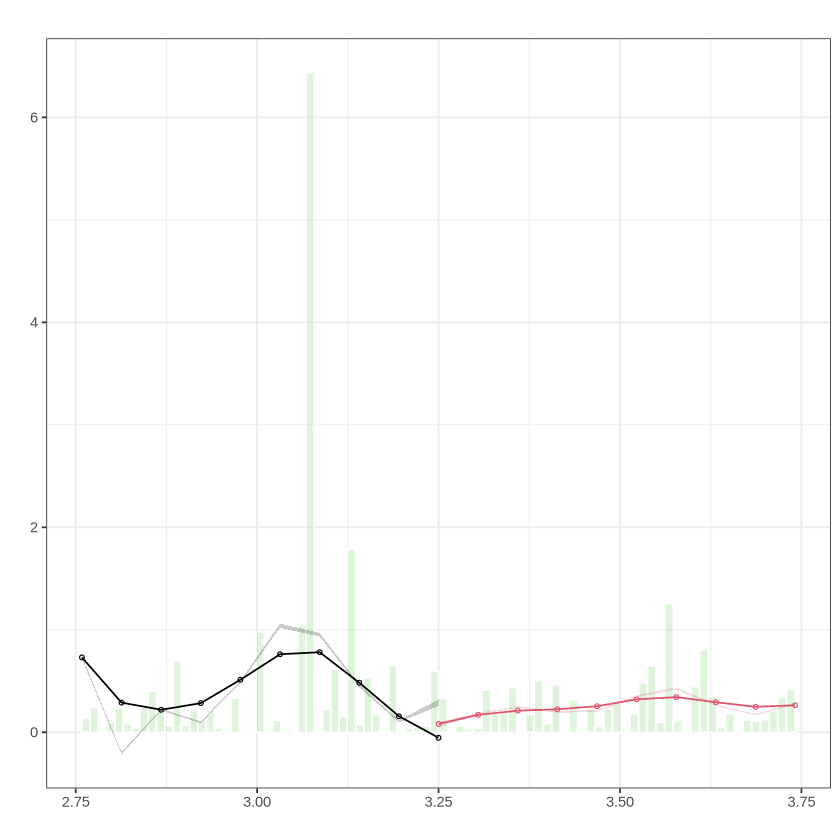

In [12]:
# 1. Density test and plot for 2.75 cutoff
dens_test_275 <- rddensity(X = data_cleaned$raw_score, c = 2.75)
dens_plot_275 <- rdplotdensity(rdd = dens_test_275, 
                               X = data_cleaned$raw_score,   # Changed from df$score to df$raw_score
                               type = "both") 

# 2. Density test and plot for 3.25 cutoff
dens_test_325 <- rddensity(X = data_cleaned$raw_score, c = 3.25)
dens_plot_325 <- rdplotdensity(rdd = dens_test_325, 
                               X = data_cleaned$raw_score,   # Changed from df$score to df$raw_score
                               type = "both")



For the 3-star plans there is a bit more of a jump at the cutoff than for the 3.5-star plans. It appears as though there is a decrease after the 2.75 threshold that does not exist at the 3.25 threshold.

# Question 9: Examine if plans just above the threshold values have different characteristics than contracts just below the threshold values using HMO and Part D status
Examine whether plans just above the threshold values have different characteristics than contracts just below the threshold values. Use HMO and Part D status as your plan characteristics.

In [13]:
data_cleaned <- data_cleaned %>%
  mutate(
    is_hmo = if_else(grepl("HMO", plan_type, ignore.case = TRUE), 1, 0),
    is_partd = if_else(partd == "Yes" | partd == 1, 1, 0)
  )

# Tests for 2.75 Threshold (3-Star) 
bal_hmo_275 <- rdrobust(y = data_cleaned$is_hmo, x = data_cleaned$raw_score, c = 2.75)
bal_partd_275 <- rdrobust(y = data_cleaned$is_partd, x = data_cleaned$raw_score, c = 2.75)

# Tests for 3.25 Threshold (3.5-Star)
bal_hmo_325 <- rdrobust(y = data_cleaned$is_hmo, x = data_cleaned$raw_score, c = 3.25)
bal_partd_325 <- rdrobust(y = data_cleaned$is_partd, x = data_cleaned$raw_score, c = 3.25)

summary(bal_hmo_275)
summary(bal_partd_275)
summary(bal_hmo_325)
summary(bal_partd_325)

Warning message in rdrobust(y = data_cleaned$is_hmo, x = data_cleaned$raw_score, :
“Mass points detected in the running variable.”
Warning message in rdrobust(y = data_cleaned$is_partd, x = data_cleaned$raw_score, :
“Mass points detected in the running variable.”
Warning message in rdrobust(y = data_cleaned$is_hmo, x = data_cleaned$raw_score, :
“Mass points detected in the running variable.”
Warning message in rdrobust(y = data_cleaned$is_partd, x = data_cleaned$raw_score, :
“Mass points detected in the running variable.”


Sharp RD estimates using local polynomial regression.

Number of Obs.                93892
BW type                       mserd
Kernel                   Triangular
VCE method                       NN

Number of Obs.                54873        39019
Eff. Number of Obs.             418          793
Order est. (p)                    1            1
Order bias  (q)                   2            2
BW est. (h)                   0.024        0.024
BW bias (b)                   0.129        0.129
rho (h/b)                     0.186        0.186
Unique Obs.                      76          187

        Method     Coef. Std. Err.         z     P>|z|      [ 95% C.I. ]       
  Conventional     0.780     0.018    42.880     0.000     [0.745 , 0.816]     
        Robust         -         -    43.315     0.000     [0.753 , 0.825]     
Sharp RD estimates using local polynomial regression.

Number of Obs.                93892
BW type                       mserd
Kernel                   Triangular
VCE 

# Question 10: Summary of findings for 5-9
Summarize your findings from 5-9. What is the effect of increasing a star rating on enrollments? Briefly explain your results.

From the current analysis, star ratings don't impact enrollments significantly. Above and below the threshold are not statistically different. This is shown through the distributions of plans and across bandwidths.